# Question 4

## Free-flight Sampling and Range Reduction

In Monte Carlo neutron transport, the distance $s$ a neutron travels before its next collision (free-flight distance) is sampled from the distribution:

$$ p(s) = e^{-\Sigma_t s} $$

where $\Sigma_t$ is the total macroscopic cross section.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Part 1

In [3]:
# 1
def trunc_exp(x, N):
    """
    Truncated taylor series solution for e^x
    Args:
    x (float): argument we want to solve e^x for
    N (int): polynomial order we want to evaluate for
    """
    result = 1 # current result
    term = 1 # current term
    for k in range(1, N+1):
        term *= x / k
        result += term
    return result

In [4]:
# 2
s = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 10.0])
sig_t = 0.5 # cm^-1

n = [3,5,7,9]
# print(np.size(s))
dict2 = {"s": s}
for order in n:
    solutions = trunc_exp(-1*s*sig_t, order)
    dict2.update({f"deg({str(order)})": solutions})
    
df2 = pd.DataFrame(dict2)
df2.index = df2["s"]
df2 = df2.drop(columns=["s"])

### Computing for $e^{-\Sigma_t s}$

In [5]:
display(df2)

,deg(3),deg(5),deg(7),deg(9)
s,,,,
0.1,0.951229,0.951229,0.951229,0.951229
0.5,0.778646,0.778800,0.778801,0.778801
1.0,0.604167,0.606510,0.606531,0.606531
2.0,0.333333,0.366667,0.367857,0.367879
5.0,-0.979167,-0.165365,0.052618,0.079950
10.0,-12.333333,-12.333333,-6.132937,-1.827105


In [32]:
# 3 & 4
reference = np.exp(-1 * s * sig_t)
df3 = df2

for order in n:
    df3[f"deg({order})"] = np.abs(df2.loc[:, f"deg({order})"] - reference)
    df3 = df3.rename(columns={f"deg({order})": f"deg({order}) Absolute Error"})

pd.set_option('display.float_format', lambda x: f'{x:.5g}')
display(df3) # There was a jupyter bug where display(df3) wouldn't render properly. These three lines fix the bug and were generated with AI
pd.reset_option('display.float_format')  # clean up after

df4 = df3
for order in n:
    df4[f"deg({order}) Absolute Error"] = np.abs(df3.loc[:, f"deg({order}) Absolute Error"] / reference)
    df4 = df4.rename(columns={f"deg({order}) Absolute Error": f"deg({order}) Relative Error"})

display(df4)

,deg(3) Absolute Error,deg(5) Absolute Error,deg(7) Absolute Error,deg(9) Absolute Error
s,,,,
0.1,0.95123,2.1547e-11,9.992e-16,0
0.5,0.77865,3.2734e-07,3.6819e-10,2.5702e-13
1,0.60417,2.0243e-05,9.1756e-08,2.5737e-10
2,0.33333,0.0012128,2.2298e-05,2.5246e-07
5,0.97917,0.24745,0.029467,0.0021349
10,12.333,12.34,6.1397,1.8338


,deg(3) Relative Error,deg(5) Relative Error,deg(7) Relative Error,deg(9) Relative Error
s,,,,
0.1,1.000000,2.265219e-11,1.050431e-15,0.000000e+00
0.5,0.999801,4.203158e-07,4.727614e-10,3.300159e-13
1.0,0.996102,3.337514e-05,1.512805e-07,4.243360e-10
2.0,0.906094,3.296663e-03,6.061310e-05,6.862545e-07
5.0,11.928692,3.014553e+00,3.589801e-01,2.600896e-02
10.0,1830.428962,1.831429e+03,9.112085e+02,2.721665e+02


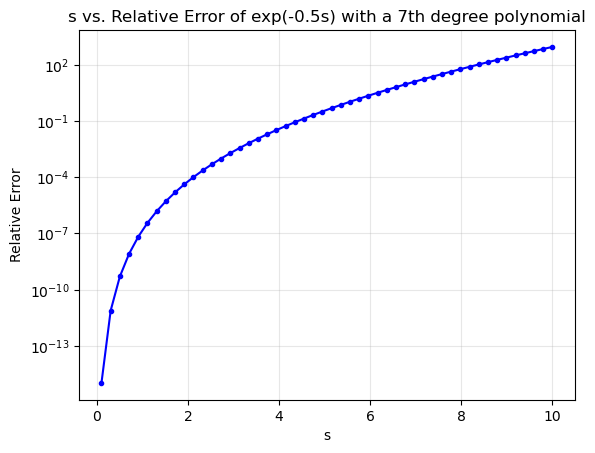

In [31]:
# 5
resolution = 50
s5 = np.linspace(0.1, 10, resolution)
reference5 = np.exp(-1*s5*sig_t)
xs = s5

values = trunc_exp(-1*s5*sig_t, 7)
abs_error5 = np.abs(values - reference5)
rel_error5 = abs_error5 / reference5
ys = rel_error5

plt.plot(xs, ys, marker=".",
                 color="blue")
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.title("s vs. Relative Error of exp(-0.5s) with a 7th degree polynomial")
plt.xlabel("s")
plt.ylabel("Relative Error")
plt.show()

### Problem 6
We begin to see about a 10% relative error at around $s=5$
### Problem 7
As s gets further from the expansion point (0), we need more and more Taylor terms to keep accuracy.

## Part 2

In [8]:
# 1
ln2 = 0.69314718
def range_reduction(x, N=5):
    """
    Range reduction solution for e^-x
    Args:
    x (float): argument we want to solve e^-x for
    N (int): polynomial order we want to evaluate for
    """
    n = np.round(x / ln2)
    r = x - n*ln2
    
    result = 1 # first term of 1
    term = 1 # current term in series
    for k in range(1, N+1):
        term *= r / k
        result += term
    return result * 2**n

In [9]:
# 2
dict_rr = {"s": s}

for order in n:
    solutions = range_reduction(-1*s, order)
    dict_rr.update({f"deg({str(order)})": solutions})
    
df_rr = pd.DataFrame(dict_rr)
df_rr.index = df_rr["s"]
df_rr = df_rr.drop(columns=["s"])

### Computing for $e^{-s}$

In [10]:
display(df_rr)

,deg(3),deg(5),deg(7),deg(9)
s,,,,
0.1,0.904833,0.904837,0.904837,0.904837
0.5,0.606501,0.606531,0.606531,0.606531
1.0,0.367706,0.367879,0.367879,0.367879
2.0,0.135335,0.135335,0.135335,0.135335
5.0,0.006738,0.006738,0.006738,0.006738
10.0,0.000045,0.000045,0.000045,0.000045


In [11]:
df_abs_error = df_rr
reference_rr = np.exp(-1*s)
for order in n:
    df_abs_error[f"deg({order})"] = np.abs(df_rr.loc[:, f"deg({order})"] - reference_rr)
    df_abs_error = df_abs_error.rename(columns={f"deg({order})": f"deg({order}) Absolute Error"})

display(df_abs_error)

df_rel_error = df_abs_error
for order in n:
    df_rel_error[f"deg({order}) Absolute Error"] = df_abs_error.loc[:, f"deg({order}) Absolute Error"] / reference_rr
    df_rel_error = df_rel_error.rename(columns={f"deg({order}) Absolute Error": f"deg({order}) Relative Error"})

display(df_rel_error)

,deg(3) Absolute Error,deg(5) Absolute Error,deg(7) Absolute Error,deg(9) Absolute Error
s,,,,
0.1,4.084703e-06,1.369293e-09,2.451372e-13,1.110223e-16
0.5,3.015172e-05,3.741421e-08,3.641687e-10,3.396341e-10
1.0,1.739252e-04,5.554557e-07,1.148495e-09,2.069845e-10
2.0,2.110058e-07,2.714791e-10,2.273460e-10,2.273411e-10
5.0,1.515721e-07,1.379389e-10,2.645398e-11,2.641019e-11
10.0,1.840698e-08,5.498083e-11,4.421167e-13,3.559851e-13


,deg(3) Relative Error,deg(5) Relative Error,deg(7) Relative Error,deg(9) Relative Error
s,,,,
0.1,0.000005,1.513303e-09,2.709186e-13,1.226986e-16
0.5,0.000050,6.168560e-08,6.004127e-10,5.599620e-10
1.0,0.000473,1.509885e-06,3.121932e-09,5.626422e-10
2.0,0.000002,2.005975e-09,1.679873e-09,1.679836e-09
5.0,0.000022,2.047195e-08,3.926119e-09,3.919619e-09
10.0,0.000405,1.211033e-06,9.738268e-09,7.841094e-09


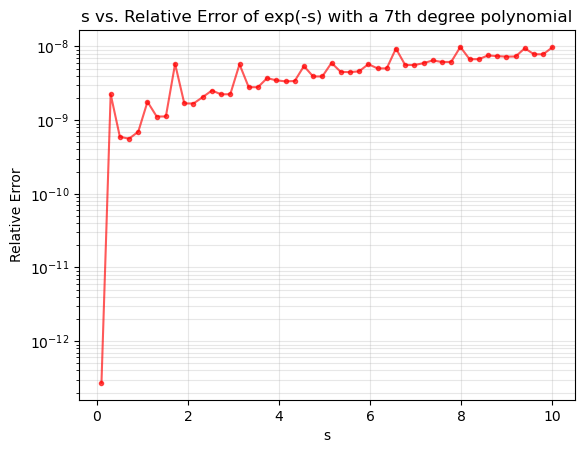

In [16]:
s_new = np.linspace(0.1, 10, resolution)
reference_new = np.exp(-1*s_new)
xs_new = s_new

values = range_reduction(-1*s_new, 7)
abs_error_new = np.abs(values - reference_new)
rel_error_new = abs_error_new / reference_new
ys_new = rel_error_new

plt.plot(xs_new, ys_new, marker=".",
                 color="red", alpha=0.65)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.title("s vs. Relative Error of exp(-s) with a 7th degree polynomial")
plt.xlabel("s")
plt.ylabel("Relative Error")
plt.show()